## Exploratory data analysis(EDA) on plasmodium vivax simulated datasets
Data are often not clean or ready to be used for machine learning predictions. However, this dataset is somewhat different. Although it is structured based on an evolutionary scenario (A, B, C, D, E), we still need to explore it to better understand its features, impute missing values, examine the distributions, and, most importantly, determine whether the classes are balanced. Ultimately, we want the model to perform at its best capabilities and ensure that poor data quality does not negatively affect its performance.

1.Below I included all the relevant libriries I used to explore the data and which visualisations helped me in analysing the data further.
Pandas is used for data manipulation
StandardScaler is used to normalize numerical features.


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

2.Load datasets.
Each dataset corresponds to a different demographic model (E–I)

In [76]:
df_E = pd.read_csv("~/downloads/simulation_summary_statsE.tsv", sep="\t")
df_F = pd.read_csv("~/downloads/simulation_summary_statsF.tsv", sep="\t")
df_G = pd.read_csv("~/downloads/simulation_summary_statsG.tsv", sep="\t")
df_H = pd.read_csv("~/downloads/simulation_summary_statsH.tsv", sep="\t")
df_I = pd.read_csv("~/downloads/simulation_summary_statsI.tsv", sep="\t")


1.Assign labels to each dataset

Here, we manually tag each dataset (E → I) so that after merging, we still know where each row originally came from.
This is especially important for supervised learning tasks.

In [77]:

df_E["label"] = "E"
df_F["label"] = "F"
df_G["label"] = "G"
df_H["label"] = "H"
df_I["label"] = "I"




2.Combine all datasets into one

 We concatenate all datasets vertically (row-wise).After combining, we reset the index so it runs from 0 → n.


In [78]:
df = pd.concat([df_E, df_F, df_G, df_H, df_I], axis=0)
df.reset_index(drop=True, inplace=True)

print("Combined shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))

Combined shape: (100000, 18)

First 10 rows:
     pi_col   pi_ebro  Tajimas_col  Tajimas_ebro  Segregating_sites_col  \
0  0.001919  0.000711     1.177224      0.014992                  0.006   
1  0.002251  0.002311    -0.392490     -1.388181                  0.014   
2  0.002224  0.003911     0.871438     -1.687186                  0.008   
3  0.001763  0.005200    -0.537607     -1.975831                  0.012   
4  0.000158  0.000800    -1.223813     -1.400851                  0.004   
5  0.001179  0.003244    -0.829104     -0.972735                  0.010   
6  0.001256  0.005333    -1.029190     -1.406879                  0.012   
7  0.000404  0.051511    -0.734180      1.710521                  0.004   
8  0.000415  0.002311    -0.711668     -1.388181                  0.004   
9  0.001693  0.002711    -0.605762     -1.492887                  0.012   

   Segregating_sites_ebro       Fst  Bin_1_col  Bin_5_col  Bin_2_col  \
0                   0.002  0.299548   0.960396   0.039604

3.Check for missing values

We count how many missing values exist in each column.this helps us decide how to handle incomplete data.


In [79]:
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns with missing values



Missing values per column:
Tajimas_col     888
Tajimas_ebro     10
dtype: int64


4.Separate features (X) and labels (y)
X = all input variables (features)
y = the target variable (labels E–I)

In [80]:
X = df.drop(columns=["label"])
y = df["label"]




5.Keep only numeric features

Machine learning models require numeric input.Here we automatically filter out non-numeric columns.


In [81]:
X = X.select_dtypes(include=["number"])

print("\nNumeric columns being used:")
print(X.columns)




Numeric columns being used:
Index(['pi_col', 'pi_ebro', 'Tajimas_col', 'Tajimas_ebro',
       'Segregating_sites_col', 'Segregating_sites_ebro', 'Fst', 'Bin_1_col',
       'Bin_5_col', 'Bin_2_col', 'Bin_3_col', 'Bin_4_col', 'Bin_1_ebro',
       'Bin_2_ebro', 'Bin_5_ebro', 'Bin_3_ebro', 'Bin_4_ebro'],
      dtype='str')



 6.Handle missing values

We replace missing values with the median of each column.Median is robust to outliers, making it a safe choice.


In [82]:
X = X.fillna(X.median())

 7.Scale features

StandardScaler transforms data so that: - mean = 0and - standard deviation = 1.This ensures all features contribute equally to models.
Most importantly the dataframe is converted into numerical features,so that the machine learning algorithm can perform their tasks


In [83]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




10.Final validation checks
 We confirm:
 - dataset shape
 - preview of data
 - no missing values remain


12.In this section of the notebook I will use three methods used for reducing the dataset dimensions so to find patterns .
I will start with PCA(principal component analysis)
then t-SNE (t-distributed Stochastic Neighbor Embedding)
and then UMAP.At the end I will compare which one is the most relevant in clustering/patterns detection 

to constract the PCA I use 3 number of components `pca = PCA(n_components=3)`
 







13.Below I import the relevant libriaries for dim reductio n

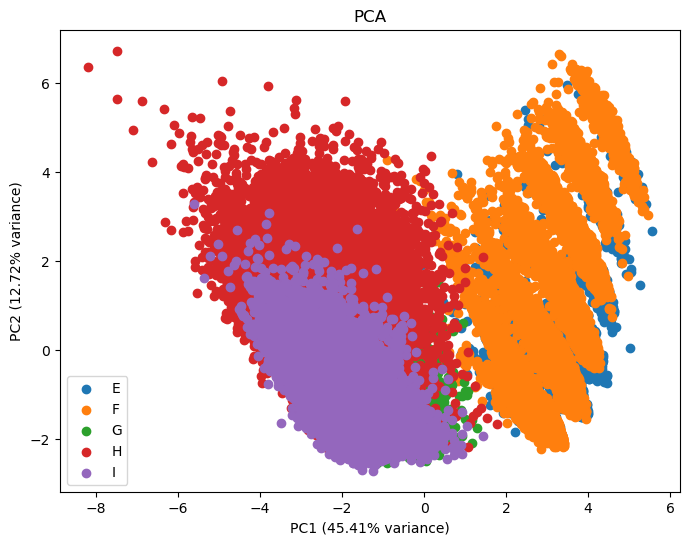

In [84]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

df['pca-one'] = pca_result[:, 0]
df['pca-two'] = pca_result[:, 1]
df['pca-three'] = pca_result[:, 2]



#plot with matplotlib
plt.figure(figsize=(8, 6))
for group in df['label'].unique():
    subset = df[df['label'] == group]
    plt.scatter(subset['pca-one'], subset['pca-two'], label=group)
#this line builds the dataframe for  the 3D PCA, I use Series/dataframe
new_data = pd.concat(
    [df['pca-one'], df['pca-two'], df['pca-three'], df['label']],
    axis=1
)



plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA')
plt.legend()
plt.show()

#plot with plotly 
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser" #force plotly to open in browser





PCA IN 3D using Plotly 

In [28]:
# 5. Plot with Plotly


fig = px.scatter_3d(new_data,
    x='pca-one',
    y='pca-two',
    z='pca-three',
    color='label',
    title='3D PCA Plot',
    labels={
        'pca-one': f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        'pca-two': f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        'pca-three': f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)'
    }
)

fig.show()

In this section I subset the labels(EFGHI) into y for machine learning

In [29]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=500)

X_tsne = tsne.fit_transform(X_scaled)



In [ ]:
plot_df = df.copy()
plot_df['tsne1'] = X_tsne[:, 0]
plot_df['tsne2'] = X_tsne[:, 1]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for group in plot_df['label'].unique():
    subset = plot_df[plot_df['label'] == group]
    plt.scatter(subset['tsne1'], subset['tsne2'], label=group)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE after PCA')
plt.legend()
plt.show()

/opt/anaconda3/envs/pvivax_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/pvivax_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


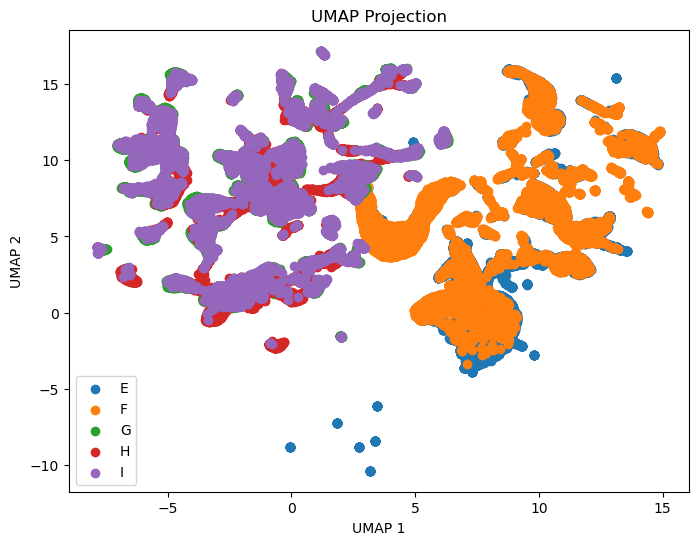

In [50]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# 3. Apply UMAP
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

# 4. Store results
plot_df = df.copy()
plot_df['umap1'] = X_umap[:, 0]
plot_df['umap2'] = X_umap[:, 1]
plot_df['umap3'] = X_umap[:, 2]

# 5. Plot
plt.figure(figsize=(8, 6))

for group in plot_df['label'].unique():
    subset = plot_df[plot_df['label'] == group]
    plt.scatter(subset['umap1'], subset['umap2'], label=group)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.title('UMAP Projection')
plt.legend()
plt.show()

Decidion tree machine learning to test accuracy
train_test_split → defines data split
`test_size` refers to the portion of the data that we want to use for training,the `train_size` could be used instead,the algorith if`train size is not provided assume the data for the training are for example the reimaning 80 percent.
then to make the code reproducible we use `random state` instead of `numpy.random`.as we want to be consistent and reproduce the same random test train set along the machine learning workflow.


model.fit → trains on X_train
model.predict → predicts on X_test
In scikit-learn, predict() is used after you train a model with fit(). It takes new input data X and returns the model’s predicted output.
For a classifier, predict() returns class labels like 0/1 or "benign"/"pathogenic". For a regressor, it returns numeric values. Scikit-learn’s getting-started guide uses exactly this fit-then-predict workflow.
accuracy_score → evaluates on test data
accuracy_score measures how many predictions the model got correct.the basic idea is that accuracy is given by number of correct prediction over total prediction.
-classification report 
Although the model achieved high accuracy (92%), this may be misleading due to class imbalance. Therefore, precision, recall, and F1-score were also evaluated to better assess performance.F1 is is the "harmonic mean" of precision and sensitivity.


In [85]:
#import relevant modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3.Create model
model_one = DecisionTreeClassifier(random_state=42)

# 4.Train
classifier_1=model_one.fit(X_train, y_train)

# 5.Predict(to use to plot confusion matrix)
y_pred = model_one.predict(X_test)
y_true=y_test
print(y_pred)
print(y_true)
# 6.Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

from sklearn.metrics import classification_report
#7.classification report 
print(classification_report(y_test, y_pred))

train_acc = model_one.score(X_train, y_train)
test_acc = model_one.score(X_test, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

['H' 'I' 'E' ... 'F' 'G' 'G']
75721    H
80184    I
19864    E
76699    H
92991    I
        ..
32595    F
29313    F
37862    F
53421    G
42410    G
Name: label, Length: 20000, dtype: str
Accuracy: 0.91545
              precision    recall  f1-score   support

           E       0.92      0.93      0.92      4018
           F       0.93      0.91      0.92      4015
           G       0.90      0.91      0.91      4002
           H       0.95      0.94      0.95      3987
           I       0.88      0.87      0.88      3978

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000

Train accuracy: 1.0
Test accuracy: 0.91545


Plot confusion matrix 


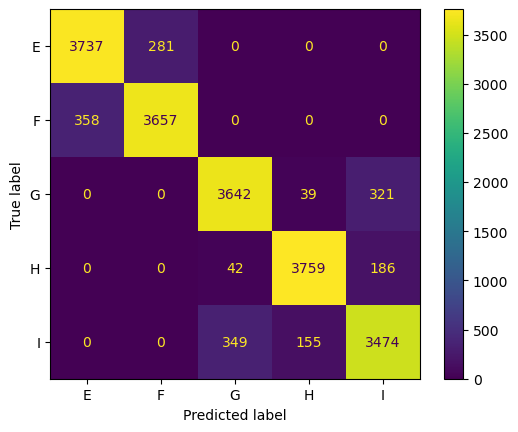

In [ ]:
#import metrics from the sklearn module
from sklearn import metrics
#Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC)
# from prediction scores.
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()


Confusion matrix using seaborn 



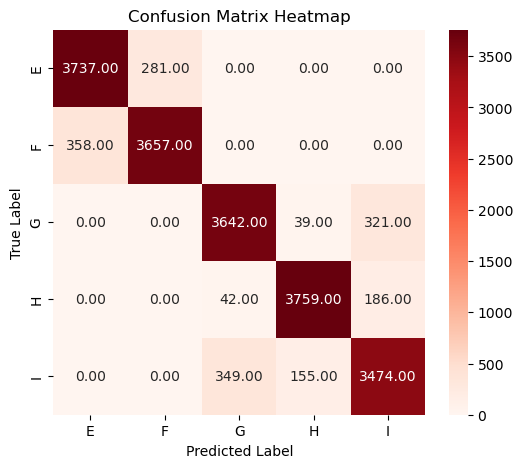

In [46]:
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt='.2f',         #format normalised,could be also int 'd'
    cmap='Reds',
    xticklabels=["E","F","G","H","I"],
    yticklabels=["E","F","G","H","I"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")

plt.show()

/opt/anaconda3/envs/pvivax_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


Below I import cross_val_score 
It test the model several time in different splits of the data,Cross-validation will tell you:

is 0.91 consistent?
or just lucky split?

In [88]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Define models (NOT fitted yet)
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC()
}

# Loop through models
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.3f}")

Decision Tree: 0.915
Random Forest: 0.942
SVC: 0.914


Visualise the tree

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
import graphviz #brew install graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

graph = graphviz.Source(dot_data)
graph